## 1. Data Pipeline & Preparation

In [1]:
# 1. Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 2. Cleaning and preparing the data
def load_and_clean_data(filepath):
    # Load raw dataset
    raw_df = pd.read_csv(filepath, encoding='ISO-8859-1')
    df = raw_df.copy()

    # Renaming country values and removing duplicates
    df['Country'] = df['Country'].replace({'RSA': 'South Africa', 'EIRE': 'Ireland'})
    df = df.drop_duplicates()

    # Keeping valid sales and rows with a description
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    df = df.dropna(subset=['Description'])

    # Converting InvoiceDate to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

    # Calculating revenue
    df['Revenue'] = df['Quantity'] * df['UnitPrice']

    # Removing administrative and postage codes
    admin_codes = ['AMAZONFEE', 'B', 'DOT', 'M', 'POST', 'S', 'm']
    df_products = df[~df['StockCode'].isin(admin_codes)].copy()

    # Loading the raw data to identify cancelled orders
    grouped = raw_df.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().reset_index()
    zero_net_orders = grouped[grouped['Quantity'] == 0][['CustomerID', 'StockCode']]

    # Removing cancelled orders
    merged = df_products.merge(
    zero_net_orders, 
    on=['CustomerID', 'StockCode'], 
    how='left', 
    indicator=True
    )
    clean_df = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge']).copy()

    return clean_df

In [3]:
# 3. Running the data pipeline
clean_df = load_and_clean_data('../data/raw/E-commerce_data.csv')
print(f"Data pipeline executed successfully. Cleaned records: {clean_df.shape[0]:,}")

Data pipeline executed successfully. Cleaned records: 521,208


#### Data Pipeline Results

* Status: The data pipeline ran successfully without errors.
* Result: The raw data was cleaned by removing duplicates, administrative & management codes, and cancelled transactions. The cleaned data is stored in `clean_df` and is ready for aggregation.


## 2. Checking the Data Quality

In [4]:
# 4. Grouping transactions into weekly revenue totals
weekly_revenue = clean_df.groupby(pd.Grouper(key='InvoiceDate', freq='W-SUN'))['Revenue'].sum().reset_index()

In [5]:
# 5. Checking the number of weeks and the final weeks
print("Total weeks:", len(weekly_revenue))
weekly_revenue.tail(3)

Total weeks: 54


,InvoiceDate,Revenue
51,2011-11-27,302007.22
52,2011-12-04,309178.71
53,2011-12-11,315258.31


In [6]:
# 6. Inspecting the early January weeks around the holiday closure
weekly_revenue.iloc[1:6]

,InvoiceDate,Revenue
1,2010-12-12,299903.65
2,2010-12-19,206093.42
3,2010-12-26,85359.48
4,2011-01-02,0.00
5,2011-01-09,128343.35


In [7]:
# 7. Checking transactions during the holiday closure period
holiday_gap = clean_df[(clean_df['InvoiceDate'] >= '2010-12-24') & (clean_df['InvoiceDate'] <= '2011-01-03')]

print("Transactions during holiday gap:", len(holiday_gap))

Transactions during holiday gap: 0


#### Investigation of £0 Holiday Week

There are 0 transactions between December 23, 2010 and January 4, 2011. This confirms the store was closed for the annual holiday period. The £0 revenue for the week ending 2011-01-02 is a real operational shutdown, not missing data.

In [8]:
# 8. Creating two weekly data versions: zero revenue vs estimated revenue

# Removing the last incomplete week
weekly_base = weekly_revenue.iloc[:-1].copy()

# Version A: Keep the holiday week at £0
weekly_zero = weekly_base.copy()

# Version B: Estimate the holiday week's revenue
weekly_interp = weekly_base.copy()
weekly_interp['Revenue'] = weekly_interp['Revenue'].replace(0, np.nan).interpolate()

# Comparing the holiday week in both versions
display(weekly_zero.iloc[2:5])
display(weekly_interp.iloc[2:5])

,InvoiceDate,Revenue
2,2010-12-19,206093.42
3,2010-12-26,85359.48
4,2011-01-02,0.00


,InvoiceDate,Revenue
2,2010-12-19,206093.420
3,2010-12-26,85359.480
4,2011-01-02,106851.415


#### Data Pipeline & Preparation Summary

* Data Cleaning: Loaded the e-commerce data, standardized country names, removed duplicates, and filtered out fees and cancelled orders.
* Weekly Data: Grouped transactions by week and calculated total revenue for each week.
* Removed Incomplete Week: Removed the final week (`2011-12-11`) because it only had 5 days of data, leaving 53 full weeks (which becomes 52 weeks for modeling after creating the lag features).
* Two Revenue Versions:
    * Version A (Zero Revenue): Kept the holiday week (`2011-01-02`) at £0 because the business was closed.
    * Version B (Estimated Revenue): Estimated the holiday week's revenue using the surrounding weeks.

## 3. Feature Engineering & Split

In [9]:
# 9. Adding previous week revenue as a feature to both versions
weekly_zero['Prior_Week_Revenue'] = weekly_zero['Revenue'].shift(1)
weekly_interp['Prior_Week_Revenue'] = weekly_interp['Revenue'].shift(1)

# Viewing the first few rows of both versions
print("Version A (Zero Revenue):")
display(weekly_zero.head())

print("Version B (Estimated Revenue):")
display(weekly_interp.head())

Version A (Zero Revenue):


,InvoiceDate,Revenue,Prior_Week_Revenue
0,2010-12-05,180384.87,NaN
1,2010-12-12,299903.65,180384.87
2,2010-12-19,206093.42,299903.65
3,2010-12-26,85359.48,206093.42
4,2011-01-02,0.00,85359.48


Version B (Estimated Revenue):


,InvoiceDate,Revenue,Prior_Week_Revenue
0,2010-12-05,180384.870,NaN
1,2010-12-12,299903.650,180384.87
2,2010-12-19,206093.420,299903.65
3,2010-12-26,85359.480,206093.42
4,2011-01-02,106851.415,85359.48


In [10]:
# 10. Removing the first empty row from both versions
weekly_zero = weekly_zero.dropna().reset_index(drop=True)
weekly_interp = weekly_interp.dropna().reset_index(drop=True)

# Viewing the first few rows of both versions
print("Version A (Zero Revenue):")
display(weekly_zero.head())

print("Version B (Estimated Revenue):")
display(weekly_interp.head())

Version A (Zero Revenue):


,InvoiceDate,Revenue,Prior_Week_Revenue
0,2010-12-12,299903.65,180384.87
1,2010-12-19,206093.42,299903.65
2,2010-12-26,85359.48,206093.42
3,2011-01-02,0.00,85359.48
4,2011-01-09,128343.35,0.00


Version B (Estimated Revenue):


,InvoiceDate,Revenue,Prior_Week_Revenue
0,2010-12-12,299903.650,180384.870
1,2010-12-19,206093.420,299903.650
2,2010-12-26,85359.480,206093.420
3,2011-01-02,106851.415,85359.480
4,2011-01-09,128343.350,106851.415


In [11]:
# 11. Checking the total number of weeks
print("Version A total weeks:", len(weekly_zero))
print("Version B total weeks:", len(weekly_interp))

Version A total weeks: 52
Version B total weeks: 52


In [12]:
# 12. Splitting both versions into 80% training and 20% testing data
split_idx = int(len(weekly_zero) * 0.8)

# Version A split
train_zero = weekly_zero.iloc[:split_idx]
test_zero = weekly_zero.iloc[split_idx:]

# Version B split
train_interp = weekly_interp.iloc[:split_idx]
test_interp = weekly_interp.iloc[split_idx:]

print(f"Split index: {split_idx}")
print("Version A shapes - Train:", train_zero.shape, "Test:", test_zero.shape)
print("Version B shapes - Train:", train_interp.shape, "Test:", test_interp.shape)

Split index: 41
Version A shapes - Train: (41, 3) Test: (11, 3)
Version B shapes - Train: (41, 3) Test: (11, 3)


#### Feature Engineering and Train/Test Split
* Prior Week Revenue: Created Prior_Week_Revenue using the previous week's revenue.
* First Row: Removed the first row because there is no previous week to use.
* 80/20 Split: Used the first 80% of weeks for training and the last 20% for testing. The data was kept in time order so the model only uses past data to predict future revenue.

In [13]:
# 13. Set the input feature and target for both versions

# Version A (Zero Revenue)
X_train_zero = train_zero[['Prior_Week_Revenue']]
y_train_zero = train_zero['Revenue']
X_test_zero = test_zero[['Prior_Week_Revenue']]
y_test_zero = test_zero['Revenue']

# Version B (Estimated Revenue)
X_train_interp = train_interp[['Prior_Week_Revenue']]
y_train_interp = train_interp['Revenue']
X_test_interp = test_interp[['Prior_Week_Revenue']]
y_test_interp = test_interp['Revenue']

# Confirm feature shapes
print("Version A input sizes (Train, Test):", X_train_zero.shape, X_test_zero.shape)
print("Version B input sizes (Train, Test):", X_train_interp.shape, X_test_interp.shape)

Version A input sizes (Train, Test): (41, 1) (11, 1)
Version B input sizes (Train, Test): (41, 1) (11, 1)


## 4. Baseline & Model Training

In [14]:
# 14. Evaluating a simple baseline using last week's revenue as the prediction

# Version A (Zero Revenue) baseline scores
baseline_mae_zero = mean_absolute_error(y_test_zero, X_test_zero['Prior_Week_Revenue'])
baseline_rmse_zero = np.sqrt(mean_squared_error(y_test_zero, X_test_zero['Prior_Week_Revenue']))
baseline_r2_zero = r2_score(y_test_zero, X_test_zero['Prior_Week_Revenue'])

# Version B (Estimated Revenue) baseline scores
baseline_mae_interp = mean_absolute_error(y_test_interp, X_test_interp['Prior_Week_Revenue'])
baseline_rmse_interp = np.sqrt(mean_squared_error(y_test_interp, X_test_interp['Prior_Week_Revenue']))
baseline_r2_interp = r2_score(y_test_interp, X_test_interp['Prior_Week_Revenue'])

# Display results
print("Version A (Zero Revenue)")
print("Baseline MAE:", round(baseline_mae_zero, 2))
print("Baseline RMSE:", round(baseline_rmse_zero, 2))
print("Baseline R^2:", round(baseline_r2_zero, 4))

print("\nVersion B (Estimated Revenue)")
print("Baseline MAE:", round(baseline_mae_interp, 2))
print("Baseline RMSE:", round(baseline_rmse_interp, 2))
print("Baseline R^2:", round(baseline_r2_interp, 4))

Version A (Zero Revenue)
Baseline MAE: 62939.95
Baseline RMSE: 72474.15
Baseline R^2: -1.0109

Version B (Estimated Revenue)
Baseline MAE: 62939.95
Baseline RMSE: 72474.15
Baseline R^2: -1.0109


#### Baseline and Model Choice
* Baseline: Used the previous week's revenue as the prediction for the current week. This provides a simple comparison for the model.
* MVP Model: Used Simple Linear Regression as the first model because it is simple and easy to understand. This allows me to see if the model can improve predictions before trying a more complex model.

In [15]:
# 15. Training Linear Regression models on both versions

# Model A: Version A (Zero Revenue)
model_zero = LinearRegression()
model_zero.fit(X_train_zero, y_train_zero)

# Model B: Version B (Estimated Revenue)
model_interp = LinearRegression()
model_interp.fit(X_train_interp, y_train_interp)

# Comparing model details
print("Version A (Zero Revenue) Details:")
print(f"Slope: {model_zero.coef_[0]:.4f}")
print(f"Intercept: {model_zero.intercept_:.2f}")

print("\nVersion B (Estimated Revenue) Details:")
print(f"Slope: {model_interp.coef_[0]:.4f}")
print(f"Intercept: {model_interp.intercept_:.2f}")

Version A (Zero Revenue) Details:
Slope: 0.3598
Intercept: 98265.72

Version B (Estimated Revenue) Details:
Slope: 0.3239
Intercept: 105481.50


In [16]:
# 16. Generate predictions for both versions
y_pred_zero = model_zero.predict(X_test_zero)
y_pred_interp = model_interp.predict(X_test_interp)

# Comparing actual values with predictions
test_preview = pd.DataFrame({
'Actual_Revenue': y_test_zero.values,
'Simple_Baseline': X_test_zero['Prior_Week_Revenue'].values,
'Pred_Version_A': y_pred_zero,
'Pred_Version_B': y_pred_interp
}, index=test_zero['InvoiceDate'])

display(test_preview.head())

,Actual_Revenue,Simple_Baseline,Pred_Version_A,Pred_Version_B
InvoiceDate,,,,
2011-09-25,323011.281,222694.530,178401.802459,177621.423037
2011-10-02,205991.391,323011.281,214500.538885,210118.146495
2011-10-09,308751.900,205991.391,172391.218920,172210.589018
2011-10-16,215433.650,308751.900,209369.335660,205498.946248
2011-10-23,263989.730,215433.650,175788.992627,175269.325236


## 5. Model Evaluation & Findings

In [17]:
# 17. Evaluating both models and compare with the baseline

# Version A scores
mae_zero = mean_absolute_error(y_test_zero, y_pred_zero)
rmse_zero = np.sqrt(mean_squared_error(y_test_zero, y_pred_zero))
r2_zero = r2_score(y_test_zero, y_pred_zero)

# Version B scores
mae_interp = mean_absolute_error(y_test_interp, y_pred_interp)
rmse_interp = np.sqrt(mean_squared_error(y_test_interp, y_pred_interp))
r2_interp = r2_score(y_test_interp, y_pred_interp)

# Create a comparison table
results_comparison = pd.DataFrame({
'Model': [
'Simple Baseline',
'Linear Regression (Version A: Zero Revenue)',
'Linear Regression (Version B: Estimated Revenue)'
],
'MAE': [round(baseline_mae_zero, 2), round(mae_zero, 2), round(mae_interp, 2)],
'RMSE': [round(baseline_rmse_zero, 2), round(rmse_zero, 2), round(rmse_interp, 2)],
'R-squared': [round(baseline_r2_zero, 4), round(r2_zero, 4), round(r2_interp, 4)]
})

display(results_comparison)

,Model,MAE,RMSE,R-squared
0,Simple Baseline,62939.95,72474.15,-1.0109
1,Linear Regression (Version A: Zero Revenue),91790.05,104923.48,-3.2146
2,Linear Regression (Version B: Estimated Revenue),93910.00,107165.98,-3.3967


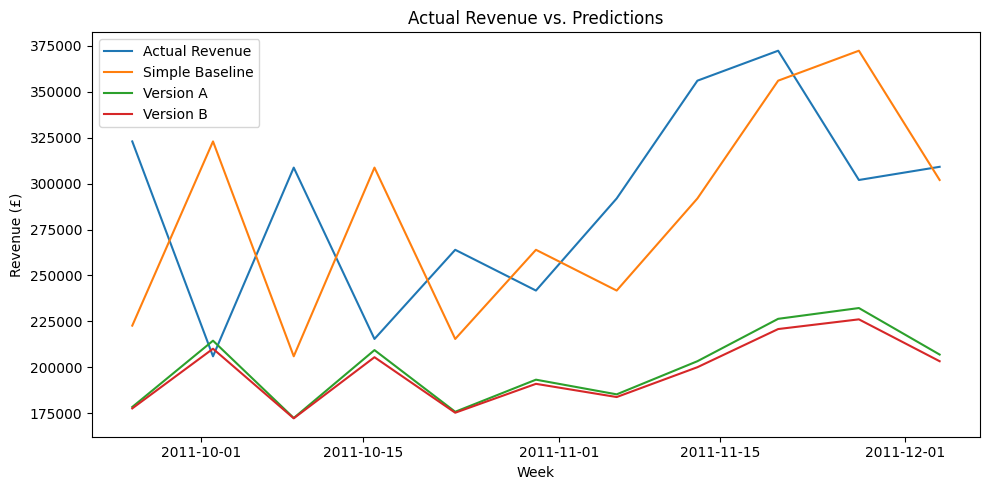

In [18]:
# 18. Plotting actual revenue and model predictions
plt.figure(figsize=(10, 5))
plt.plot(test_zero['InvoiceDate'], y_test_zero.values, label='Actual Revenue')
plt.plot(test_zero['InvoiceDate'], X_test_zero['Prior_Week_Revenue'].values, label='Simple Baseline')
plt.plot(test_zero['InvoiceDate'], y_pred_zero, label='Version A')
plt.plot(test_zero['InvoiceDate'], y_pred_interp, label='Version B')

plt.title('Actual Revenue vs. Predictions')
plt.xlabel('Week')
plt.ylabel('Revenue (£)')
plt.legend()
plt.tight_layout()
plt.show()

### Findings

The baseline model shows that using the previous week's revenue was a better starting point for predicting weekly revenue than the linear regression models tested. The baseline had a lower MAE of £62.9k, while the two linear models had MAEs of £91.8k and £93.9k. This shows that last week's revenue provides useful information about the following week's revenue.

The results also show that previous week's revenue alone is not enough to explain changes in sales. In the chart, the baseline follows the actual revenue with a one week delay. The linear regression models stay mostly between £175k and £230k and miss the large increase in November sales. This caused the linear models to perform poorly during the later part of the year. Version A, which kept the holiday week at £0, performed slightly better than Version B, which estimated the holiday revenue.

There are still some limitations. The models use only one feature and do not include seasonal patterns or retail holidays. Adding more previous week features and calendar information could help improve future predictions.